<a href="https://colab.research.google.com/github/jigme42/Biomass/blob/main/Tree_detection_v1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Install libraries that are needed  

In [ ]:
!pip install rasterio

In [ ]:
!pip install scikit-image

# Import the required libraries.

In [ ]:
import numpy as np # for numerical operations
import matplotlib.pyplot as plt # for visualizing images
import tensorflow as tf  # provides the deep learning framework to build the UNet model.
from tensorflow.keras import layers, models
from skimage.measure import label # label connected components in the binary mask (for tree counting).
from rasterio.plot import show
import rasterio # reading geospatial raster data (ortho and CHM images).
from osgeo import gdal #read geospatial data (TIFF images).
from skimage.measure import label, regionprops
from google.colab import drive

# Mounting google drive to access the data to be used.

In [ ]:
# Mount Google Drive to access your 'Learning' folder
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Load ortho image (RGB + possibly NIR)
with rasterio.open('/content/drive/MyDrive/Learning/ortho_masked.tif') as src:
    ortho_image = src.read()  # Shape: (4, height, width)

# Load CHM image (Canopy Height Model)
with rasterio.open('/content/drive/MyDrive/Learning/chm_masked.tif') as src:
    chm_image = src.read(1)  # Single band (height data), Shape: (height, width)

# Extract Metadata from the Ortho_masked image.

Resolution: The spatial resolution of the image is retrieved, representing the size of each pixel in the coordinate system.

Projection: The coordinate reference system (CRS) is obtained, providing information on how the spatial data is projected onto the map.

Dimensions: The width and height in pixels are recorded, indicating the overall size of the image.

Band Information: The number of bands in the image, their data types, and NoData values are extracted for further analysis.

In [ ]:
import rasterio
import numpy as np

# Path to your GeoTIFF file
file_path = '/content/drive/MyDrive/Learning/ortho_masked.tif'

# Open the file and read the metadata
with rasterio.open(file_path) as src:
    # Get the resolution
    resolution = src.res  # (x_res, y_res)

    # Get the projection
    projection = src.crs  # Coordinate Reference System

    # Get image dimensions
    width = src.width
    height = src.height

    # Get band information
    num_bands = src.count
    band_data_types = [src.dtypes[i] for i in range(num_bands)]
    band_no_data_values = [src.nodata for i in range(num_bands)]

    # Initialize statistics dictionary
    stats = {}

    for i in range(1, num_bands + 1):
        band = src.read(i)
        # Calculate statistics
        stats[i] = {
            'min': np.min(band[band != band_no_data_values[i - 1]]),  # Exclude NoData values
            'max': np.max(band[band != band_no_data_values[i - 1]]),
            'mean': np.mean(band[band != band_no_data_values[i - 1]]),
            'std': np.std(band[band != band_no_data_values[i - 1]])
        }

# Print the results
print(f"Resolution: {resolution[0]} (x) x {resolution[1]} (y) in units")
print(f"Projection: {projection.to_proj4() if projection else 'No projection'}")
print(f"Dimensions: {width} pixels (width) x {height} pixels (height)")
print(f"Number of Bands: {num_bands}")
print(f"Band Data Types: {band_data_types}")
print(f"Band NoData Values: {band_no_data_values}")

# Print statistics for each band
for band, stat in stats.items():
    print(f"Band {band} - Min: {stat['min']}, Max: {stat['max']}, Mean: {stat['mean']:.2f}, Std: {stat['std']:.2f}")

Resolution: 0.019760000000001384 (x) x 0.01975999999999511 (y) in units
Projection: +init=epsg:7856
Dimensions: 11982 pixels (width) x 19510 pixels (height)
Number of Bands: 4
Band Data Types: ['uint8', 'uint8', 'uint8', 'uint8']
Band NoData Values: [0.0, 0.0, 0.0, 0.0]
Band 1 - Min: 5, Max: 255, Mean: 124.08, Std: 41.61
Band 2 - Min: 19, Max: 255, Mean: 139.78, Std: 39.91
Band 3 - Min: 1, Max: 255, Mean: 83.40, Std: 33.50
Band 4 - Min: 255, Max: 255, Mean: 255.00, Std: 0.00


# Plotting the Ortho image and the CHM.

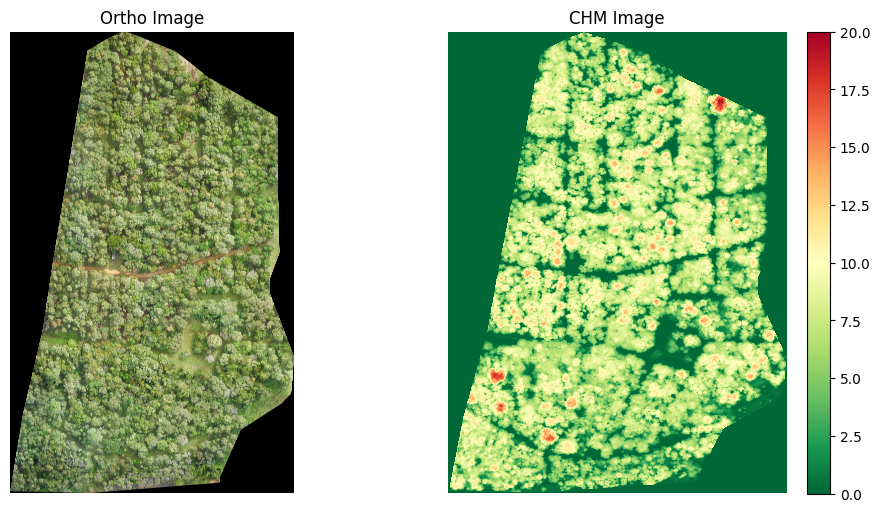

In [ ]:
#Select only the first three bands of orthophoto
ortho_image = ortho_image[:3]
# Plot the ortho image and CHM image
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(np.moveaxis(ortho_image, 0, -1))  # Only RGB channels
plt.title("Ortho Image")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(chm_image, cmap='RdYlGn_r', vmin=0, vmax=20, aspect='auto')
plt.colorbar()
plt.title("CHM Image")
plt.axis('off')
plt.show()


In [ ]:
# Combine ortho and resized CHM
ortho_band = ortho_image[0]  # Taking the first ortho band (Red)
input_image = np.stack([ortho_band, np.squeeze(chm_image_resized)], axis=-1)  # Shape: (height, width, 2)

# Define Specific Size Variables for U-Net

In [ ]:
IMG_CHANNELS = 3
IMG_WIDTH = 256
IMG_HEIGHT = 256

In [ ]:
X = np.zeros((len(ortho_image), 256, 256, 3), dtype=np.uint8)

[[[[0 0 0]
   [0 0 0]
   [0 0 0]
   ...
   [0 0 0]
   [0 0 0]
   [0 0 0]]

  [[0 0 0]
   [0 0 0]
   [0 0 0]
   ...
   [0 0 0]
   [0 0 0]
   [0 0 0]]

  [[0 0 0]
   [0 0 0]
   [0 0 0]
   ...
   [0 0 0]
   [0 0 0]
   [0 0 0]]

  ...

  [[0 0 0]
   [0 0 0]
   [0 0 0]
   ...
   [0 0 0]
   [0 0 0]
   [0 0 0]]

  [[0 0 0]
   [0 0 0]
   [0 0 0]
   ...
   [0 0 0]
   [0 0 0]
   [0 0 0]]

  [[0 0 0]
   [0 0 0]
   [0 0 0]
   ...
   [0 0 0]
   [0 0 0]
   [0 0 0]]]


 [[[0 0 0]
   [0 0 0]
   [0 0 0]
   ...
   [0 0 0]
   [0 0 0]
   [0 0 0]]

  [[0 0 0]
   [0 0 0]
   [0 0 0]
   ...
   [0 0 0]
   [0 0 0]
   [0 0 0]]

  [[0 0 0]
   [0 0 0]
   [0 0 0]
   ...
   [0 0 0]
   [0 0 0]
   [0 0 0]]

  ...

  [[0 0 0]
   [0 0 0]
   [0 0 0]
   ...
   [0 0 0]
   [0 0 0]
   [0 0 0]]

  [[0 0 0]
   [0 0 0]
   [0 0 0]
   ...
   [0 0 0]
   [0 0 0]
   [0 0 0]]

  [[0 0 0]
   [0 0 0]
   [0 0 0]
   ...
   [0 0 0]
   [0 0 0]
   [0 0 0]]]


 [[[0 0 0]
   [0 0 0]
   [0 0 0]
   ...
   [0 0 0]
   [0 0 0]
   [0 0 0]]

  [[0 0

# The U-Net model
The model being used is the U-Net model which requires the input image to be 256 by 256. The Ortho-masked image is resized to fit into the model.
The U-Net model is a convolutional neural network designed for image segmentation, particularly effective in applications like biomedical imaging and remote sensing.

Its architecture consists of an encoder for feature extraction through convolutional and pooling layers, followed by a decoder that upsamples the feature maps using transposed convolutions. A key feature is the skip connections, which concatenate encoder and decoder features, preserving spatial information.

This design enables precise pixel-wise classification, making U-Net highly robust even with limited training data. Its versatility allows for various applications, such as tree canopy segmentation and land cover classification.

In [ ]:
# Resize input image to match model input shape
input_image_resized = tf.image.resize(input_image, size=(256, 256))
input_image_resized = np.expand_dims(input_image_resized, axis=0)  # Add batch dimension

In [ ]:
def unet_model(input_size=(256, 256, 2)):
    inputs = tf.keras.layers.Input(input_size)

    # Encoder
    conv1 = tf.keras.layers.Conv2D(64, (3, 3), padding='same')(inputs)
    conv1 = tf.keras.layers.ReLU()(conv1)
    conv1 = tf.keras.layers.Conv2D(64, (3, 3), padding='same')(conv1)
    conv1 = tf.keras.layers.ReLU()(conv1)
    pool1 = tf.keras.layers.MaxPooling2D(pool_size=(2, 2))(conv1)

    conv2 = tf.keras.layers.Conv2D(128, (3, 3), padding='same')(pool1)
    conv2 = tf.keras.layers.ReLU()(conv2)
    conv2 = tf.keras.layers.Conv2D(128, (3, 3), padding='same')(conv2)
    conv2 = tf.keras.layers.ReLU()(conv2)
    pool2 = tf.keras.layers.MaxPooling2D(pool_size=(2, 2))(conv2)

    conv3 = tf.keras.layers.Conv2D(256, (3, 3), padding='same')(pool2)
    conv3 = tf.keras.layers.ReLU()(conv3)
    conv3 = tf.keras.layers.Conv2D(256, (3, 3), padding='same')(conv3)
    conv3 = tf.keras.layers.ReLU()(conv3)
    pool3 = tf.keras.layers.MaxPooling2D(pool_size=(2, 2))(conv3)

    conv4 = tf.keras.layers.Conv2D(512, (3, 3), padding='same')(pool3)
    conv4 = tf.keras.layers.ReLU()(conv4)
    conv4 = tf.keras.layers.Conv2D(512, (3, 3), padding='same')(conv4)
    conv4 = tf.keras.layers.ReLU()(conv4)
    pool4 = tf.keras.layers.MaxPooling2D(pool_size=(2, 2))(conv4)

    conv5 = tf.keras.layers.Conv2D(1024, (3, 3), padding='same')(pool4)
    conv5 = tf.keras.layers.ReLU()(conv5)
    conv5 = tf.keras.layers.Conv2D(1024, (3, 3), padding='same')(conv5)
    conv5 = tf.keras.layers.ReLU()(conv5)

    # Decoder
    up6 = tf.keras.layers.Conv2DTranspose(512, (2, 2), strides=(2, 2), padding='same')(conv5)
    merge6 = tf.keras.layers.Concatenate()([conv4, up6])
    conv6 = tf.keras.layers.Conv2D(512, (3, 3), padding='same')(merge6)
    conv6 = tf.keras.layers.ReLU()(conv6)
    conv6 = tf.keras.layers.Conv2D(512, (3, 3), padding='same')(conv6)
    conv6 = tf.keras.layers.ReLU()(conv6)

    up7 = tf.keras.layers.Conv2DTranspose(256, (2, 2), strides=(2, 2), padding='same')(conv6)
    merge7 = tf.keras.layers.Concatenate()([conv3, up7])
    conv7 = tf.keras.layers.Conv2D(256, (3, 3), padding='same')(merge7)
    conv7 = tf.keras.layers.ReLU()(conv7)
    conv7 = tf.keras.layers.Conv2D(256, (3, 3), padding='same')(conv7)
    conv7 = tf.keras.layers.ReLU()(conv7)

    up8 = tf.keras.layers.Conv2DTranspose(128, (2, 2), strides=(2, 2), padding='same')(conv7)
    merge8 = tf.keras.layers.Concatenate()([conv2, up8])
    conv8 = tf.keras.layers.Conv2D(128, (3, 3), padding='same')(merge8)
    conv8 = tf.keras.layers.ReLU()(conv8)
    conv8 = tf.keras.layers.Conv2D(128, (3, 3), padding='same')(conv8)
    conv8 = tf.keras.layers.ReLU()(conv8)

    up9 = tf.keras.layers.Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same')(conv8)
    merge9 = tf.keras.layers.Concatenate()([conv1, up9])
    conv9 = tf.keras.layers.Conv2D(64, (3, 3), padding='same')(merge9)
    conv9 = tf.keras.layers.ReLU()(conv9)
    conv9 = tf.keras.layers.Conv2D(64, (3, 3), padding='same')(conv9)
    conv9 = tf.keras.layers.ReLU()(conv9)

    # Final layer
    outputs = tf.keras.layers.Conv2D(1, (1, 1), activation='sigmoid')(conv9)

    model = tf.keras.Model(inputs=[inputs], outputs=[outputs])
    return model

In [ ]:
# Create the model
model = unet_model()
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Summary of the model
model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5             │ (None, 256, 256, 2)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_95 (Conv2D)        │ (None, 256, 256, 64)   │          1,216 │ input_layer_5[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ re_lu_90 (ReLU)           │ (None, 256, 256, 64)   │              0 │ conv2d_95[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_96 (Conv2D)        │ (None, 256, 256, 64)   │         36,928 │ re_lu_90[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ re_lu_91 (ReLU)           │ (None, 256, 256, 64)   │              0 │ conv2d_96[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_20          │ (None, 128, 128, 64)   │              0 │ re_lu_91[0][0]         │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_97 (Conv2D)        │ (None, 128, 128, 128)  │         73,856 │ max_pooling2d_20[0][0] │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ re_lu_92 (ReLU)           │ (None, 128, 128, 128)  │              0 │ conv2d_97[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_98 (Conv2D)        │ (None, 128, 128, 128)  │        147,584 │ re_lu_92[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ re_lu_93 (ReLU)           │ (None, 128, 128, 128)  │              0 │ conv2d_98[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_21          │ (None, 64, 64, 128)    │              0 │ re_lu_93[0][0]         │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_99 (Conv2D)        │ (None, 64, 64, 256)    │        295,168 │ max_pooling2d_21[0][0] │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ re_lu_94 (ReLU)           │ (None, 64, 64, 256)    │              0 │ conv2d_99[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_100 (Conv2D)       │ (None, 64, 64, 256)    │        590,080 │ re_lu_94[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ re_lu_95 (ReLU)           │ (None, 64, 64, 256)    │              0 │ conv2d_100[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_22          │ (None, 32, 32, 256)    │              0 │ re_lu_95[0][0]         │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_101 (Conv2D)       │ (None, 32, 32, 512)    │      1,180,160 │ max_pooling2d_22[0][0] │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ re_lu_96 (ReLU)      

 Total params: 31,031,169 (118.37 MB)

 Trainable params: 31,031,169 (118.37 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Prediction Block
predicted_mask = model.predict(input_image_resized)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


In [ ]:
# Threshold the predicted mask to create a binary mask
threshold = 0.5
binary_mask = (predicted_mask[0] > threshold).astype(np.uint8)  # Shape: (256, 256)

In [ ]:
# Label the connected components in the binary mask
labeled_mask = label(binary_mask)

In [ ]:
# After your segmentation and labeling steps
# Assuming `predicted_mask` is your binary mask
labeled_mask = label(predicted_mask[0] > 0.5)  # Example thresholding

# Get properties of the labeled regions
regions = regionprops(labeled_mask)

# Count the number of tree canopies
number_of_canopies = len(regions)
print(f"Number of tree canopies detected: {number_of_canopies}")

Number of tree canopies detected: 3433


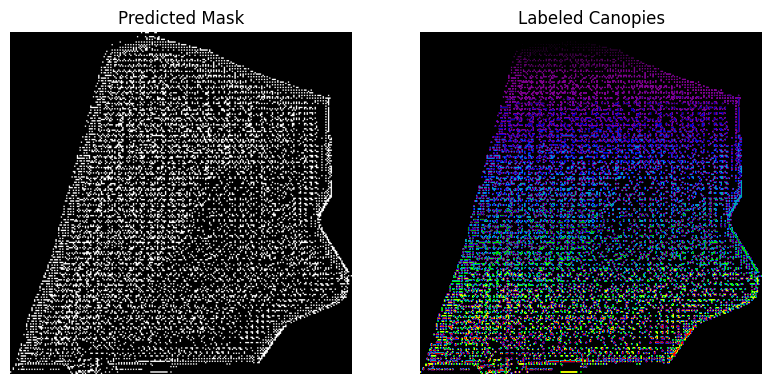

In [ ]:
# Plot the predicted mask, and labeled mask
plt.figure(figsize=(15, 5))
# Predicted Mask
plt.subplot(1, 3, 2)
plt.imshow(predicted_mask[0], cmap='gray')
plt.title("Predicted Mask")
plt.axis('off')

# Labeled Mask
plt.subplot(1, 3, 3)
plt.imshow(labeled_mask, cmap='nipy_spectral')
plt.title("Labeled Canopies")
plt.axis('off')

plt.show()

In [ ]:
import rasterio

# Load the CHM using rasterio (assuming it's a GeoTIFF file)
chm_path = ('/content/drive/MyDrive/Learning/chm_masked.tif')
with rasterio.open(chm_path) as src:
    chm = src.read(1)  # Read the first band (assuming the CHM is a single-band raster)

# Ensure CHM has been loaded
print("CHM shape:", chm.shape)

CHM shape: (1542, 946)


In [ ]:
# Define a threshold to exclude non-tree areas (e.g., ground or very small heights)
height_threshold = 1.0

# Filter out values below the threshold
tree_heights = chm[chm > height_threshold]

# Calculate statistics for tree heights only
min_height = np.min(tree_heights)
max_height = np.max(tree_heights)
median_height = np.median(tree_heights)
mean_height = np.mean(tree_heights)

# Print the results
print(f"Minimum Tree Height (excluding below {height_threshold}m): {min_height:.2f} meters")
print(f"Maximum Tree Height: {max_height:.2f} meters")
print(f"Median Tree Height: {median_height:.2f} meters")
print(f"Mean Tree Height: {mean_height:.2f} meters")

Minimum Tree Height (excluding below 1.0m): 1.00 meters
Maximum Tree Height: 20.67 meters
Median Tree Height: 7.09 meters
Mean Tree Height: 6.90 meters
